In [2]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn import datasets # <-- ADD THIS LINE


In [7]:

# Set a style for the plots
sns.set_style('whitegrid')

# Step 2: Generate synthetic data
# This ensures the example is reproducible without needing an external CSV file.
# We'll create a dataset with a clear linear trend plus some random noise.
X, y = datasets.make_regression(
    n_samples=200,      # Number of data points
    n_features=1,       # Number of independent variables (predictors)
    noise=20,           # Amount of random noise to add
    random_state=42     # For reproducibility
)

# Convert to a pandas DataFrame for easier manipulation
df = pd.DataFrame(data=X, columns=['Feature'])
df['Target'] = y

# ... the rest of your code continues from here

# Step 3: Explore and visualize the data
print("First 5 rows of the dataset:")
df.head()



First 5 rows of the dataset:


,Feature,Target
0,1.852278,137.096464
1,0.473592,59.002556
2,-1.230864,-76.592075
3,0.625667,60.803919
4,-0.072010,-8.886217


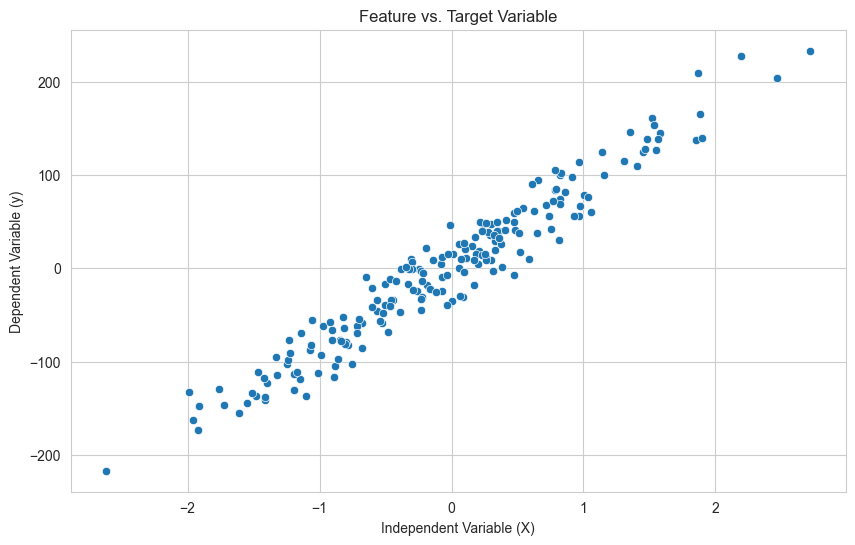

In [9]:

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Feature', y='Target', data=df)
plt.title('Feature vs. Target Variable')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (y)')
plt.show()


In [13]:

# Step 4: Prepare data for modeling
# X should be a 2D array (or DataFrame), y should be a 1D array (or Series)
X = df[['Feature']]  # Predictor
y = df['Target']     # Target

# Split the data into training and testing sets
# 80% for training, 20% for testing to evaluate the model's performance on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Create and train the model
# Instantiate the LinearRegression model
model = LinearRegression()

# Fit the model to the training data
# This is where the model learns the optimal coefficient (slope) and intercept
model.fit(X_train, y_train)

# Step 6: Inspect the model's learned parameters
print("\nModel Parameters:")
# The intercept (β₀) is the value of y when X is 0
print(f"Intercept (β₀): {model.intercept_:.2f}")
# The coefficient (β₁) is the slope of the line
print(f"Coefficient (β₁): {model.coef_[0]:.2f}")

 
y_pred = model.predict(X_test)



Model Parameters:
Intercept (β₀): 2.45
Coefficient (β₁): 86.51


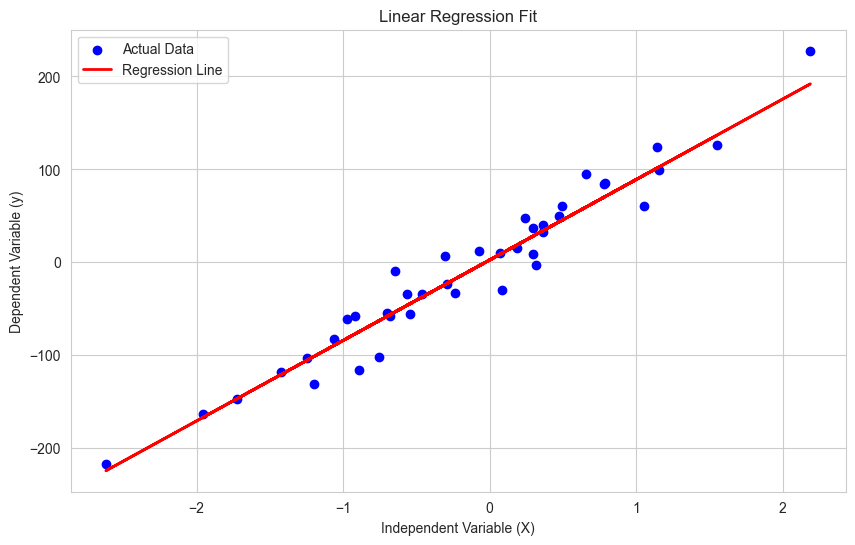

In [14]:

# Step 9: Visualize the results
# Plot the regression line on top of the actual data points
plt.figure(figsize=(10, 6))
# Scatter plot of the actual test data
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
# Plot the regression line (predictions)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression Fit')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (y)')
plt.legend()
plt.show()

In [ ]:

# Step 8: Evaluate the model's performance
print("\nModel Evaluation Metrics:")
# Mean Absolute Error (MAE)
mae = metrics.mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Mean Squared Error (MSE)
mse = metrics.mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# R-squared (R²)
r2 = metrics.r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.2f}")



Model Evaluation Metrics:
Mean Absolute Error (MAE): 16.04
Mean Squared Error (MSE): 437.55
R-squared (R²): 0.94
